In [2]:
import sys
import time
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import scipy.constants as sc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()

import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm);

In [54]:
# Parameters
sol, model, params = sim_PyBaMM.simulate_DC1(I0=0.5, T=1000, T_horizon=3600)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
Dn = sol.observe(model.variables['X-averaged negative particle effective diffusivity [m2.s-1]'])(t)[-1,0]
c0 = params['Initial concentration in negative electrode [mol.m-3]']
cn_max = params['Maximum concentration in negative electrode [mol.m-3]']
Ln = params['Negative electrode thickness [m]']
A = params['Electrode height [m]'] * params['Electrode width [m]']
Rn = params['Negative particle radius [m]']
en = params['Negative electrode active material volume fraction']
an = 3 * en / Rn

F = sc.physical_constants['Faraday constant'][0]
I = 0.5


# Non-dimensionalization
tau = Rn**2 / Dn  # Time scale
c0_tilde = c0 / cn_max
jn = I / (Dn*F*an*A*Ln) # molar flux
jn_tilde = - jn * Rn / (Dn * cn_max)  # non-dimensional flux
print(c0_tilde)

0.8000000000000016


In [55]:
class Net(nn.Module):
    def __init__(self, input_size=2, hidden_size=128):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        t_tilde = x[:, 0:1]  # (N, 1)
        r_tilde = x[:, 1:2]  # (N, 1
        raw = self.net(x)
        # Hard coded c(r, 0) = c0, instead of ic_loss
        return raw * t_tilde + c0_tilde  # c = NN(r, t) * t + c0
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )[0]

# def ic_loss(model):
#     # Initial condition u(r, 0) = c0
#     c0 = c0_tilde
#     r_ic = torch.linspace(0, 1, 100).reshape(-1, 1)
#     t_ic = torch.zeros(100, 1)
    
#     tr_ic = torch.cat([t_ic, r_ic], dim=1)
#     u_ic = model(tr_ic)
#     return torch.mean((u_ic - c0)**2)

def bc_loss(model, I):
    # r=0: du/dr = 0
    t_bc = torch.linspace(0, 1, 200).reshape(-1, 1)  # (100, 1)

    r0 = torch.zeros(200, 1).requires_grad_(True)  # r=0 boundary
    u_r0 = model(torch.cat([t_bc, r0], dim=1))
    du_dr0 = grad(u_r0, r0)
    bc_0 = torch.mean(du_dr0**2)

    # r = R: du/dr = flux
    rR = torch.ones(200, 1).requires_grad_(True)  # r=R boundary
    u_rR = model(torch.cat([t_bc, rR], dim=1))
    du_drR = grad(u_rR, rR)

    bc_R = torch.mean((du_drR - jn_tilde)**2)
    return bc_0 + bc_R

def physics_loss(y_pred, T, R):
    # compute du/dt du/dr
    du_dt = grad(y_pred, T)
    du_dr = grad(y_pred, R)
    d2u_dr2 = grad(du_dr, R)

    pde = du_dt * R - (2 * du_dr + R * d2u_dr2) # dimensionless
    return torch.mean(pde**2)

In [ ]:
# Collocation points in dimensionless form
t_1d = torch.linspace(0, 1, 100)
r_1d = torch.linspace(0, 1, 100)
T, R = torch.meshgrid(t_1d, r_1d, indexing='ij')  # each (100, 100)
T = T.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
R = R.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
TR = torch.cat([T, R], dim=1)                      # (10000, 2)

def training(epochs=50, tol=2.5e-4, model=model, optimizer=optimizer):
    history = {'loss': []}
    model.train()
    
    for epoch in range(epochs):
        y_pred = model(TR)

        p_loss = physics_loss(y_pred, T, R)
        # i_loss = ic_loss(model)
        b_loss = bc_loss(model, I=0.5)

        loss = p_loss + b_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history['loss'].append(p_loss.item())

        if epoch % 100 == 0:
            print(f'Epoch {epoch+1} loss: {p_loss:.5f}')

    return model, history

In [58]:
model, history = training(epochs=200, model=model, optimizer=optimizer)

Epoch 1 loss: 0.00467
Epoch 101 loss: 96.28450


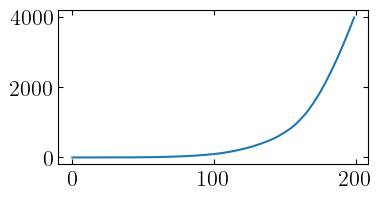

In [59]:
plt.figure(figsize=(4,2))
plt.plot(history['loss'])

(100, 100)


Text(0, 0.5, '$c_n(t, r=0.80)$')

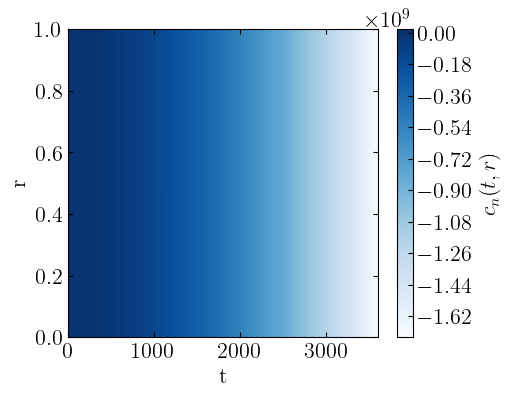

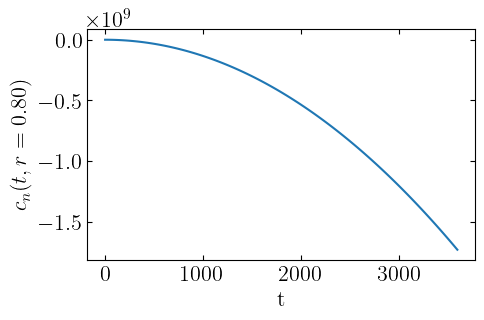

In [ ]:
t_horizon = 3600
r_horizon = 1
t_num = 100
r_num = 100
t_1d = torch.linspace(0, t_horizon, t_num)
r_1d = torch.linspace(0, r_horizon, r_num)
T_mesh, R_mesh = torch.meshgrid(t_1d, r_1d, indexing='ij')  # each (1000, 1000)
T = T_mesh.reshape(-1, 1).requires_grad_(True)          # (1000000, 1)
R = R_mesh.reshape(-1, 1).requires_grad_(True)          # (1000000, 1)
TR_test = torch.cat([T, R], dim=1)                      # (1000000, 2)

pred = model(TR_test).detach().numpy().reshape(t_num, r_num) # Shape (1000, 1000) = (t_index, r_index)
print(pred.shape)

plt.figure(figsize=(5,4))
plt.contourf(T_mesh.detach().numpy(), R_mesh.detach().numpy(), pred, levels=100, cmap='Blues')
plt.xlabel('t')
plt.ylabel('r')
plt.colorbar(label='$c_n(t,r)$')

# Fixed r plot u(t)
r_target = 0.8
r_idx = torch.argmin(torch.abs(r_1d - r_target)).item()

plt.figure(figsize=(5, 3))
plt.plot(t_1d.numpy(), pred[:, r_idx])
plt.xlabel('t')
plt.ylabel(f'$c_n(t, r={r_1d[r_idx]:.2f})$')

Relative L2 error: 192.3467


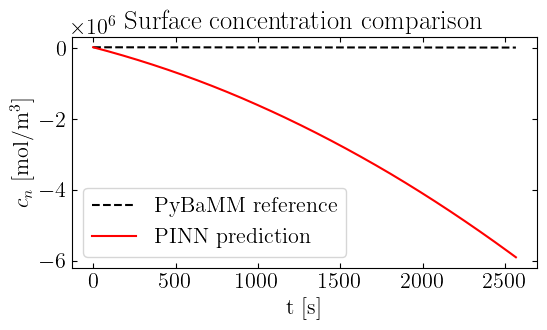

In [71]:
# --- 1. Predict in dimensionless domain ---
t_num, r_num = 200, 50
t_tilde_vals = torch.linspace(0, 1, t_num)          # t̃ ∈ [0, 1]
r_tilde_vals = torch.linspace(0, 1, r_num)          # r̃ ∈ [0, 1]

T_mesh, R_mesh = torch.meshgrid(t_tilde_vals, r_tilde_vals, indexing='ij')
TR_test = torch.cat([T_mesh.reshape(-1,1), R_mesh.reshape(-1,1)], dim=1)

c_tilde_pred = model(TR_test).detach().numpy().reshape(t_num, r_num)

# --- 2. Convert back to physical dimensions ---
t_phys = t_tilde_vals.numpy() * tau                 # t̃ → t [s]
r_phys = r_tilde_vals.numpy() * Rn                  # r̃ → r [m]
c_phys_pred = c_tilde_pred * cn_max                 # c̃ → c [mol/m^3]

# --- 3. Get PyBaMM reference in physical dimensions ---
t_ref = t_phys  # same time points
c_surf_pybamm = sol['X-averaged negative particle surface concentration [mol.m-3]'](t_ref)

# --- 4. Compare surface concentration (r̃ = 1, last r index) ---
c_surf_pinn = c_phys_pred[:, -1]                    # r̃=1 → r=Rn (surface)

plt.figure(figsize=(6, 3))
plt.plot(t_ref, c_surf_pybamm, 'k--', label='PyBaMM reference')
plt.plot(t_ref, c_surf_pinn,   'r-',  label='PINN prediction')
plt.xlabel('t [s]')
plt.ylabel('$c_n$ [mol/m$^3$]')
plt.legend()
plt.title('Surface concentration comparison')

# --- 5. Relative L2 error ---
l2_error = np.linalg.norm(c_surf_pinn - c_surf_pybamm) / np.linalg.norm(c_surf_pybamm)
print(f"Relative L2 error: {l2_error:.4f}")

In [70]:
# Check 1: tau should be O(100-10000s) for typical battery params
print(f"tau = {tau:.1f} s  (t_horizon/tau = {t_horizon/tau:.2f})")
# If t_horizon/tau >> 1, your [0,1] t̃ doesn't cover the full horizon!
# In that case use: t_tilde_max = t_horizon / tau and scale accordingly

# Check 2: flux should be small and negative for discharge
print(f"flux_tilde = {jn_tilde:.6f}")  # expect small negative number

# Check 3: IC hard constraint — c̃ at t=0 should equal c0_tilde everywhere
with torch.no_grad():
    tr_ic = torch.cat([torch.zeros(10,1), torch.linspace(0,1,10).reshape(-1,1)], dim=1)
    ic_check = model(tr_ic).numpy()
    print(f"IC check (should all be {c0_tilde:.4f}): {ic_check.flatten()}")

tau = 2566.2 s  (t_horizon/tau = 1.40)
flux_tilde = -2675848096475.575195
IC check (should all be 0.8000): [0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]


In [ ]:
# Forward (physical → dimensionless, for model input)
t_tilde = t_phys / tau          # [s]      → [-]
r_tilde = r_phys / Rn           # [m]      → [-]

# Inverse (dimensionless → physical, for model output)
t_phys  = t_tilde * tau         # [-]      → [s]
r_phys  = r_tilde * Rn          # [-]      → [m]
# c_phys  = c_tilde * cn_max      # [-]      → [mol/m^3]

NameError: name 'c_tilde' is not defined